# 02 — Exploratory Data Analysis (EDA)

**PM Accelerator — Weather Trend Forecasting**  
**Input:** data/processed/weather_cleaned.csv (from Day 1)

---

## Why EDA before modeling?

EDA answers: *What patterns exist? What should a forecast respect?*

Assessment asks for:
1. Trends, correlations, and patterns  
2. Visualizations for **temperature** and **precipitation**

We use **cleaned data in original units** (not MinMax/Standard) so charts stay interpretable (°C, mm).


## 1. Imports & load cleaned data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
CLEAN_PATH = ROOT / 'data' / 'processed' / 'weather_cleaned.csv'
OUT_DIR = ROOT / 'outputs' / 'eda'
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 4)

df = pd.read_csv(CLEAN_PATH, low_memory=False)
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['date'] = pd.to_datetime(df['date'])

print('Shape:', df.shape)
print('Time range:', df['last_updated'].min(), '→', df['last_updated'].max())
print('Countries:', df['country'].nunique(), '| Locations:', df.groupby(['country', 'location_name']).ngroups)
df.head(3)


Shape: (153775, 37)
Time range: 2024-05-16 01:45:00 → 2026-07-17 19:00:00
Countries: 211 | Locations: 286


,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,date,year,month,day_of_week
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,...,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024-05-16,2024,5,3
1,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 18:30:00,22.0,Patchy rain nearby,7.2,318,...,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024-05-16,2024,5,3
2,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-17 20:30:00,15.0,Patchy rain nearby,5.4,17,...,04:49 AM,06:51 PM,01:09 PM,01:37 AM,Waxing Gibbous,64,2024-05-17,2024,5,4


## 2. Snapshot of key weather variables

Always start with distributions: mean, median, spread, extremes.  
This becomes your baseline when you later say "the model predicts X°C."


In [2]:
key_cols = [
    'temperature_celsius',
    'precip_mm',
    'humidity',
    'pressure_mb',
    'wind_kph',
    'cloud',
    'air_quality_PM2.5',
]

summary = df[key_cols].describe().T
summary['missing'] = df[key_cols].isna().sum()
summary.round(2)


,count,mean,std,min,25%,50%,75%,max,missing
temperature_celsius,153775.0,21.37,9.48,-29.80,16.10,23.7,27.90,55.00,0
precip_mm,153775.0,0.13,0.56,0.00,0.00,0.0,0.02,42.24,0
humidity,153775.0,66.97,23.63,2.00,52.00,72.0,86.00,100.00,0
pressure_mb,153775.0,1014.03,6.90,947.00,1010.00,1014.0,1018.00,1085.00,0
wind_kph,153775.0,12.76,8.38,3.60,6.10,10.8,17.60,250.00,0
cloud,153775.0,39.49,34.09,0.00,0.00,27.0,75.00,100.00,0
air_quality_PM2.5,153775.0,23.30,35.44,0.17,6.85,13.5,26.64,1614.10,0


### What to notice
- Mean temperature ~21°C, but min ~−30°C → strong geographic diversity  
- Median precip = 0 → most snapshots are dry; rain is sparse (skewed)  
- Humidity median ~72% → typically moist conditions globally in this feed


## 3. Temperature analysis (required)

We look at temperature three ways:
1. **Distribution** — overall shape  
2. **Global daily trend** — average across all cities each day  
3. **Seasonality** — by month (expect summer/winter patterns)


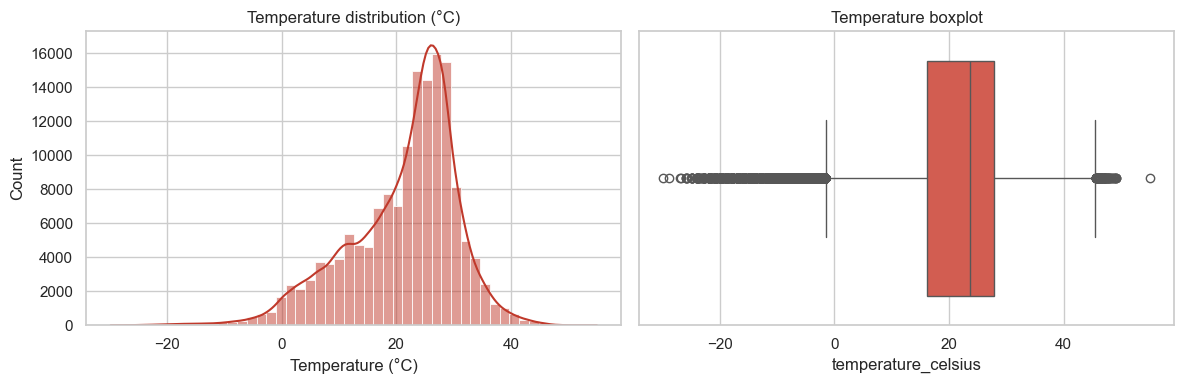

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['temperature_celsius'], bins=50, kde=True, ax=axes[0], color='#c0392b')
axes[0].set_title('Temperature distribution (°C)')
axes[0].set_xlabel('Temperature (°C)')

sns.boxplot(x=df['temperature_celsius'], ax=axes[1], color='#e74c3c')
axes[1].set_title('Temperature boxplot')

plt.tight_layout()
fig.savefig(OUT_DIR / '01_temperature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Global daily average temperature

Each day we average temperature across all locations.  
This is **not** one city's weather — it is a worldwide snapshot trend.  
Useful for: "Is the feed stable over time? Any seasonal wave?"


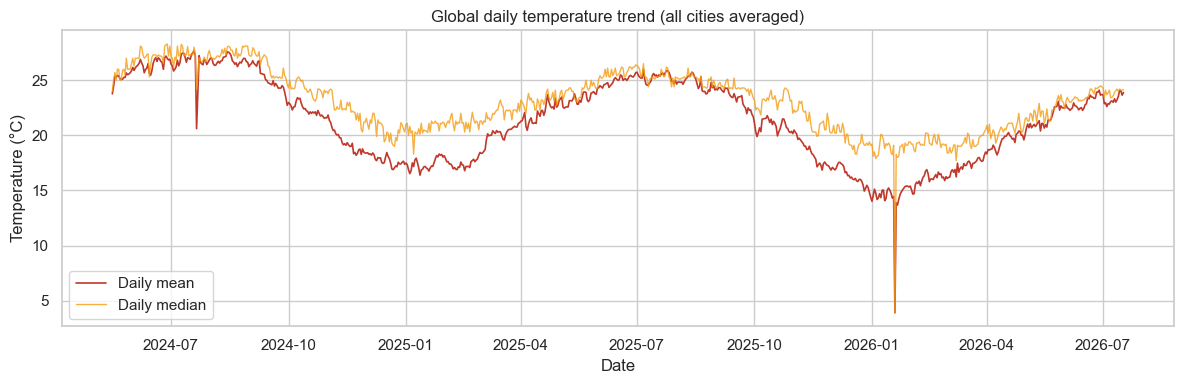

Daily mean temp range: 3.9 → 27.66


In [4]:
daily_temp = (
    df.groupby('date', as_index=False)['temperature_celsius']
    .agg(mean_temp='mean', median_temp='median', n_obs='count')
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_temp['date'], daily_temp['mean_temp'], color='#c0392b', linewidth=1.2, label='Daily mean')
ax.plot(daily_temp['date'], daily_temp['median_temp'], color='#f39c12', linewidth=1.0, alpha=0.8, label='Daily median')
ax.set_title('Global daily temperature trend (all cities averaged)')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / '02_global_daily_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

print('Daily mean temp range:', round(daily_temp['mean_temp'].min(), 2), '→', round(daily_temp['mean_temp'].max(), 2))


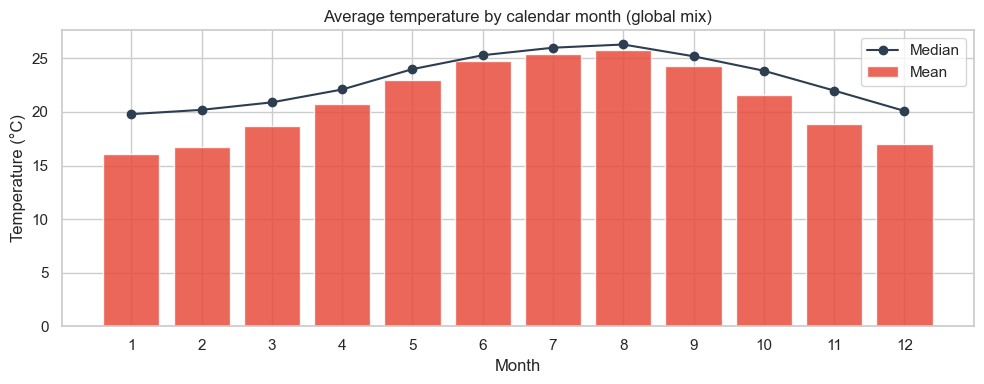

,month,mean,median,std
0,1,16.07,19.80,11.82
1,2,16.71,20.20,11.57
2,3,18.70,20.90,9.77
3,4,20.71,22.10,8.62
4,5,22.96,24.00,7.66
5,6,24.79,25.30,7.28
6,7,25.41,26.00,7.25
7,8,25.75,26.30,6.87
8,9,24.25,25.20,6.76
9,10,21.60,23.85,7.76


In [5]:
# Seasonality: month averages (1=Jan ... 12=Dec)
monthly_temp = df.groupby('month')['temperature_celsius'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_temp['month'], monthly_temp['mean'], color='#e74c3c', alpha=0.85, label='Mean')
ax.plot(monthly_temp['month'], monthly_temp['median'], color='#2c3e50', marker='o', label='Median')
ax.set_xticks(range(1, 13))
ax.set_title('Average temperature by calendar month (global mix)')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / '03_temperature_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

monthly_temp.round(2)


### Example city time series

Forecasting later will usually be **per location**.  
Pick a city with many observations and plot its temperature history.


Top locations by observation count:


,country,location_name,n_obs
36,Burundi,Bujumbura,791
260,Ukraine,Kyiv,791
278,Yemen,Sanaa,791
49,Chad,N'djamena,791
86,Ghana,Accra,791
272,Vatican City,Vatican City,791
74,Eritrea,Asmara,791
73,Equatorial Guinea,Malabo,791


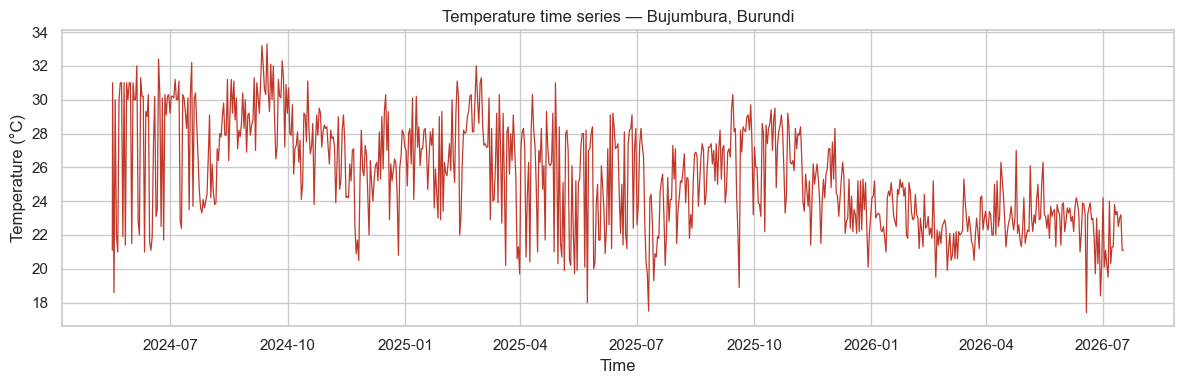

Demo city: Bujumbura, Burundi | n=791


In [6]:
coverage = (
    df.groupby(['country', 'location_name'])
    .size()
    .reset_index(name='n_obs')
    .sort_values('n_obs', ascending=False)
)
print('Top locations by observation count:')
display(coverage.head(8))

# Choose a well-covered city for a clear series
demo_country, demo_city = coverage.iloc[0]['country'], coverage.iloc[0]['location_name']
city = df[(df['country'] == demo_country) & (df['location_name'] == demo_city)].sort_values('last_updated')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(city['last_updated'], city['temperature_celsius'], color='#c0392b', linewidth=0.9)
ax.set_title(f'Temperature time series — {demo_city}, {demo_country}')
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')
plt.tight_layout()
fig.savefig(OUT_DIR / '04_city_temperature_series.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Demo city: {demo_city}, {demo_country} | n={len(city)}')


## 4. Precipitation analysis (required)

Precipitation is **zero-inflated**: many zeros, few wet days.  
That changes how we visualize and later how we model it.


In [7]:
wet = df['precip_mm'] > 0
print(f"Rows with any precip (>0 mm): {wet.sum():,} ({100*wet.mean():.1f}%)")
print(f"Rows dry (==0 mm): {(~wet).sum():,} ({100*(~wet).mean():.1f}%)")
print(f"Mean precip (all rows): {df['precip_mm'].mean():.3f} mm")
print(f"Mean precip (wet days only): {df.loc[wet, 'precip_mm'].mean():.3f} mm")


Rows with any precip (>0 mm): 50,730 (33.0%)
Rows dry (==0 mm): 103,045 (67.0%)
Mean precip (all rows): 0.132 mm
Mean precip (wet days only): 0.399 mm


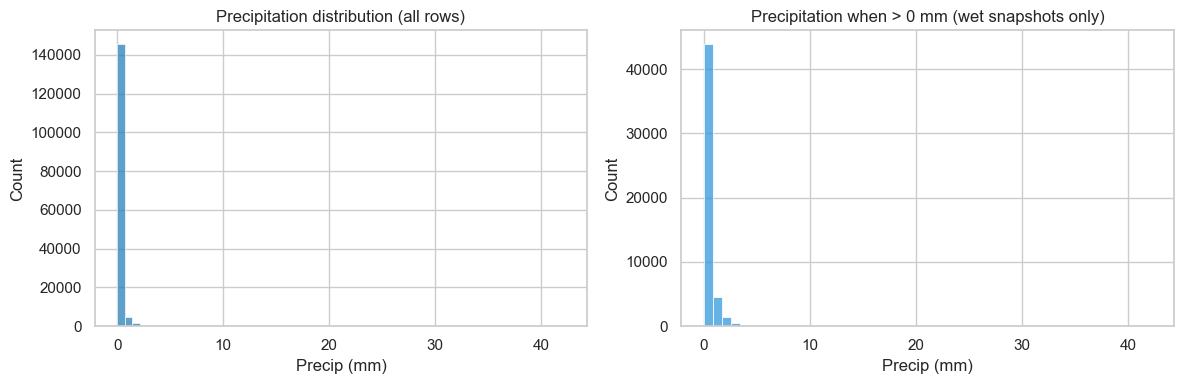

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['precip_mm'], bins=60, ax=axes[0], color='#2980b9')
axes[0].set_title('Precipitation distribution (all rows)')
axes[0].set_xlabel('Precip (mm)')

sns.histplot(df.loc[wet, 'precip_mm'], bins=50, ax=axes[1], color='#3498db')
axes[1].set_title('Precipitation when > 0 mm (wet snapshots only)')
axes[1].set_xlabel('Precip (mm)')

plt.tight_layout()
fig.savefig(OUT_DIR / '05_precipitation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


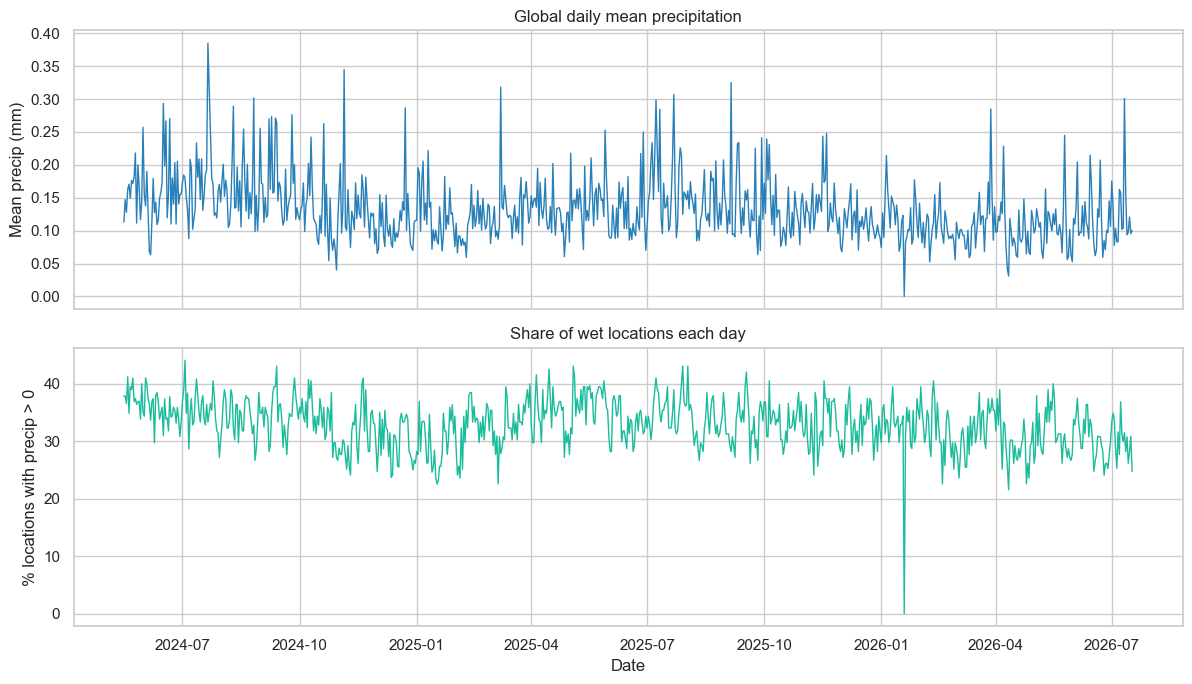

In [9]:
daily_precip = (
    df.groupby('date', as_index=False)['precip_mm']
    .agg(mean_precip='mean', total_precip='sum', wet_share=lambda s: (s > 0).mean())
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(daily_precip['date'], daily_precip['mean_precip'], color='#2980b9', linewidth=1.0)
axes[0].set_ylabel('Mean precip (mm)')
axes[0].set_title('Global daily mean precipitation')

axes[1].plot(daily_precip['date'], daily_precip['wet_share'] * 100, color='#1abc9c', linewidth=1.0)
axes[1].set_ylabel('% locations with precip > 0')
axes[1].set_xlabel('Date')
axes[1].set_title('Share of wet locations each day')

plt.tight_layout()
fig.savefig(OUT_DIR / '06_global_daily_precipitation.png', dpi=150, bbox_inches='tight')
plt.show()


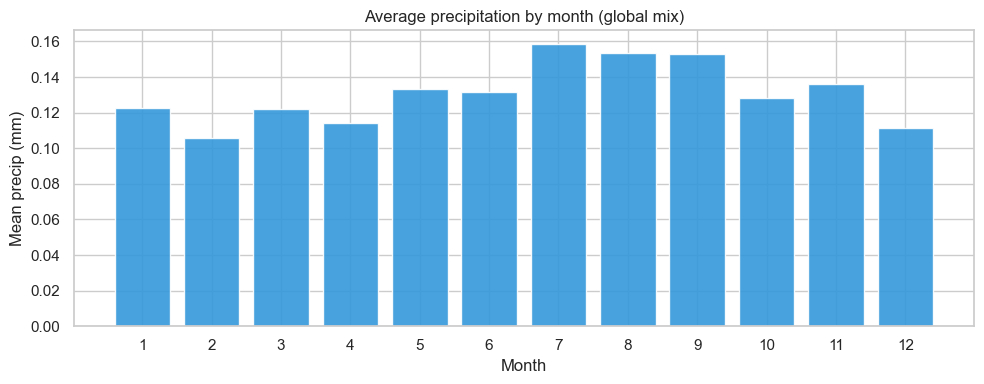

,month,mean_mm,sum_mm,wet_fraction
0,1,0.122,1450.17,0.315
1,2,0.106,1155.87,0.322
2,3,0.122,1455.43,0.324
3,4,0.114,1338.57,0.321
4,5,0.133,2050.79,0.349
5,6,0.132,2305.39,0.329
6,7,0.158,2363.95,0.343
7,8,0.154,1857.08,0.339
8,9,0.153,1790.29,0.339
9,10,0.129,1550.23,0.337


In [10]:
monthly_precip = df.groupby('month')['precip_mm'].agg(['mean', 'sum', lambda s: (s > 0).mean()]).reset_index()
monthly_precip.columns = ['month', 'mean_mm', 'sum_mm', 'wet_fraction']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_precip['month'], monthly_precip['mean_mm'], color='#3498db', alpha=0.9)
ax.set_xticks(range(1, 13))
ax.set_title('Average precipitation by month (global mix)')
ax.set_xlabel('Month')
ax.set_ylabel('Mean precip (mm)')
plt.tight_layout()
fig.savefig(OUT_DIR / '07_precipitation_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

monthly_precip.round(3)


## 5. Correlations & patterns

### What is correlation?
Pearson correlation ≈ how two numeric variables move together (from −1 to +1).

- **+1**: rise together  
- **0**: no linear relationship  
- **−1**: one rises when the other falls

**Caution:** correlation ≠ causation. Humidity and temperature can correlate without one "causing" the other.


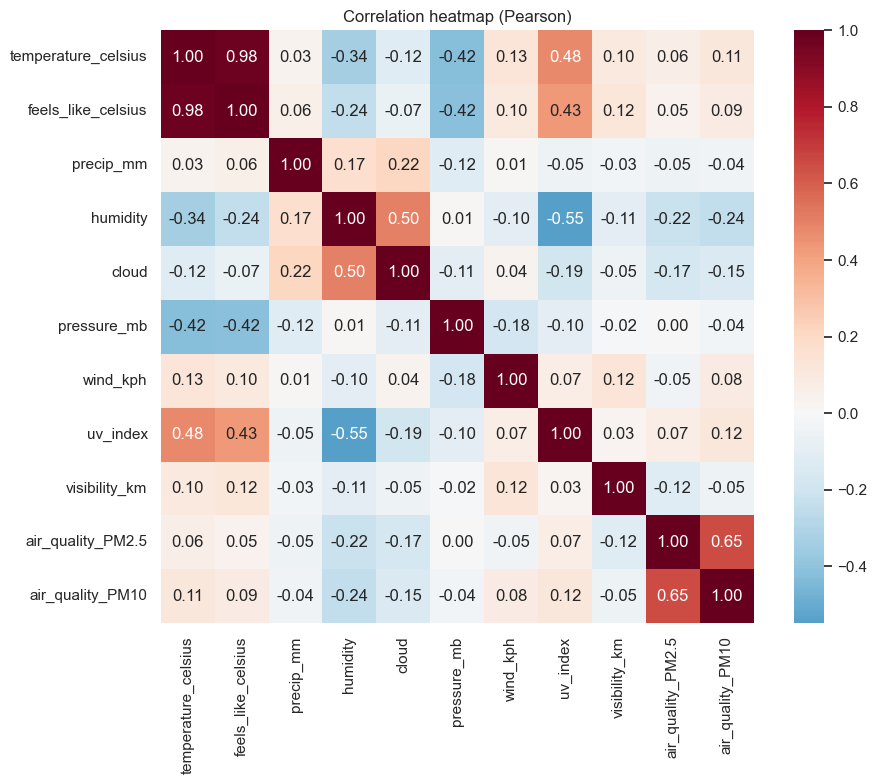

In [11]:
corr_cols = [
    'temperature_celsius',
    'feels_like_celsius',
    'precip_mm',
    'humidity',
    'cloud',
    'pressure_mb',
    'wind_kph',
    'uv_index',
    'visibility_km',
    'air_quality_PM2.5',
    'air_quality_PM10',
]

corr = df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Correlation heatmap (Pearson)')
plt.tight_layout()
fig.savefig(OUT_DIR / '08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Strongest relationships with temperature and with precipitation
temp_corr = corr['temperature_celsius'].drop('temperature_celsius').sort_values(key=abs, ascending=False)
precip_corr = corr['precip_mm'].drop('precip_mm').sort_values(key=abs, ascending=False)

print('Strongest |correlations| with temperature:')
display(temp_corr.head(8).round(3).to_frame('corr_with_temp'))

print('Strongest |correlations| with precipitation:')
display(precip_corr.head(8).round(3).to_frame('corr_with_precip'))


Strongest |correlations| with temperature:


,corr_with_temp
feels_like_celsius,0.980
uv_index,0.485
pressure_mb,-0.425
humidity,-0.340
wind_kph,0.130
cloud,-0.122
air_quality_PM10,0.114
visibility_km,0.104


Strongest |correlations| with precipitation:


,corr_with_precip
cloud,0.217
humidity,0.168
pressure_mb,-0.124
feels_like_celsius,0.061
air_quality_PM2.5,-0.052
uv_index,-0.050
air_quality_PM10,-0.043
temperature_celsius,0.034


### Scatter patterns (temperature vs related features)

Heatmaps summarize; scatters show the shape (linear, curved, clustered).


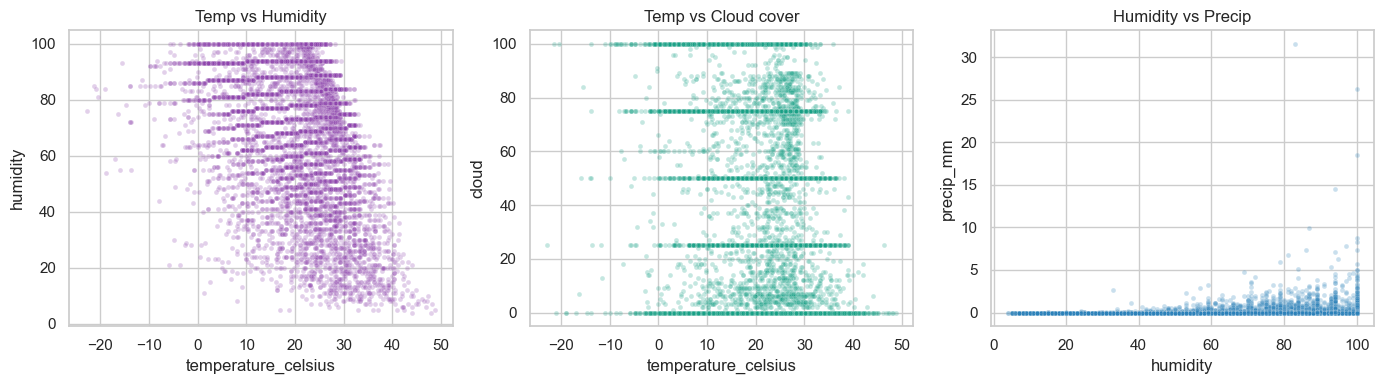

In [14]:
# Sample for readable scatters (full 150k+ points is slow and overplotted)
sample = df.sample(n=8000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.scatterplot(data=sample, x='temperature_celsius', y='humidity', alpha=0.25, s=12, ax=axes[0], color='#8e44ad')
axes[0].set_title('Temp vs Humidity')

sns.scatterplot(data=sample, x='temperature_celsius', y='cloud', alpha=0.25, s=12, ax=axes[1], color='#16a085')
axes[1].set_title('Temp vs Cloud cover')

sns.scatterplot(data=sample, x='humidity', y='precip_mm', alpha=0.25, s=12, ax=axes[2], color='#2980b9')
axes[2].set_title('Humidity vs Precip')

plt.tight_layout()
fig.savefig(OUT_DIR / '09_scatter_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Geographic pattern preview

Latitude often shapes climate (colder toward poles).  
Full spatial maps come in Advanced Day 5 — here we check a simple latitude–temperature pattern.


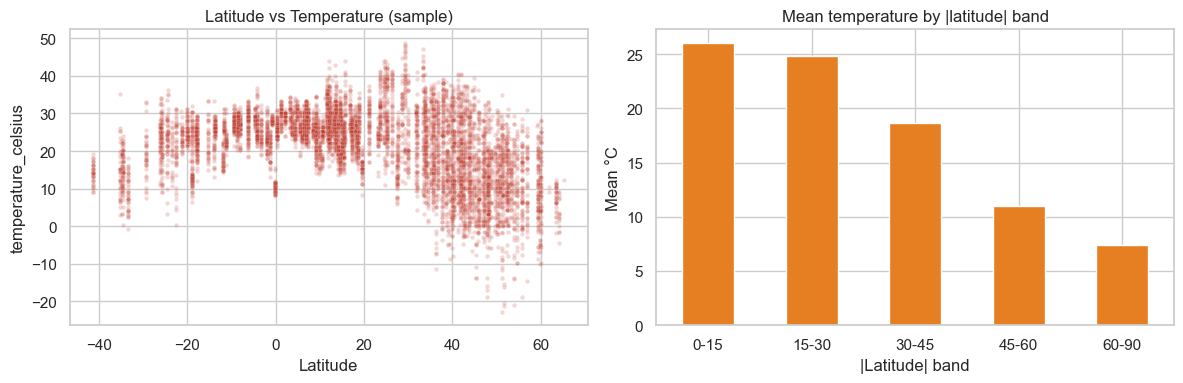

Correlation latitude vs temperature: -0.362
Correlation |latitude| vs temperature: -0.558


In [15]:
df['abs_latitude'] = df['latitude'].abs()

lat_bins = pd.cut(df['abs_latitude'], bins=[0, 15, 30, 45, 60, 90], labels=['0-15', '15-30', '30-45', '45-60', '60-90'])
lat_temp = df.groupby(lat_bins, observed=True)['temperature_celsius'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=sample, x='latitude', y='temperature_celsius', alpha=0.2, s=10, ax=axes[0], color='#c0392b')
axes[0].set_title('Latitude vs Temperature (sample)')
axes[0].set_xlabel('Latitude')

lat_temp.plot(kind='bar', ax=axes[1], color='#e67e22')
axes[1].set_title('Mean temperature by |latitude| band')
axes[1].set_xlabel('|Latitude| band')
axes[1].set_ylabel('Mean °C')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig(OUT_DIR / '10_latitude_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation latitude vs temperature:', round(df['latitude'].corr(df['temperature_celsius']), 3))
print('Correlation |latitude| vs temperature:', round(df['abs_latitude'].corr(df['temperature_celsius']), 3))


## 7. Top / bottom countries by average temperature

Quick geographic comparison for storytelling in the report.


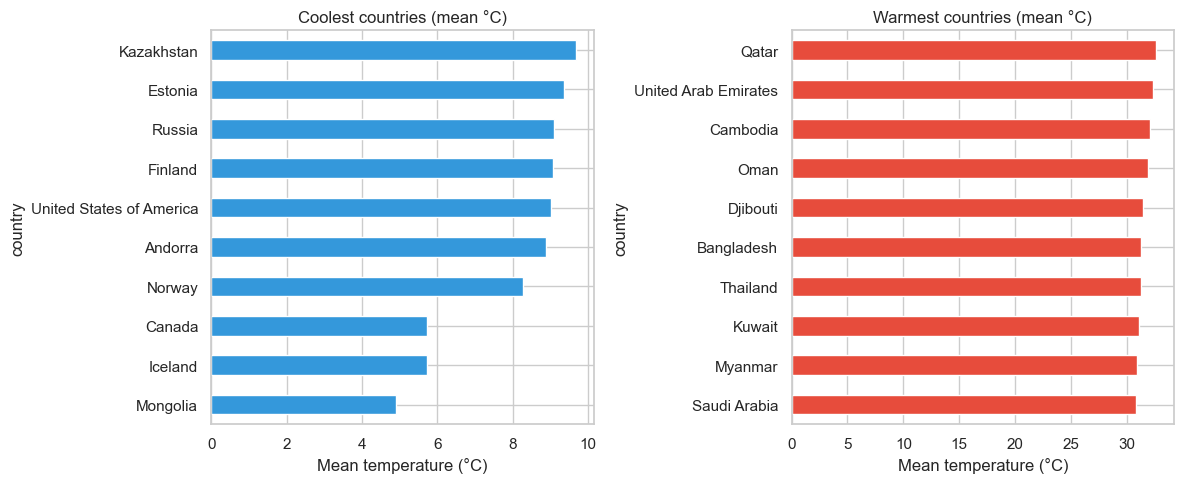

In [16]:
country_temp = (
    df.groupby('country')['temperature_celsius']
    .agg(mean_temp='mean', n='count')
    .query('n >= 200')  # enough samples for a stable average
    .sort_values('mean_temp')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

country_temp.head(10)['mean_temp'].plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Coolest countries (mean °C)')
axes[0].set_xlabel('Mean temperature (°C)')

country_temp.tail(10)['mean_temp'].plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Warmest countries (mean °C)')
axes[1].set_xlabel('Mean temperature (°C)')

plt.tight_layout()
fig.savefig(OUT_DIR / '11_country_temperature_extremes.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Save EDA summary tables

Useful later for the report / README without re-running every plot.


In [17]:
daily_temp.to_csv(OUT_DIR / 'daily_global_temperature.csv', index=False)
daily_precip.to_csv(OUT_DIR / 'daily_global_precipitation.csv', index=False)
corr.to_csv(OUT_DIR / 'correlation_matrix.csv')
country_temp.to_csv(OUT_DIR / 'country_mean_temperature.csv')

insights = {
    'n_rows': len(df),
    'n_countries': int(df['country'].nunique()),
    'n_locations': int(df.groupby(['country', 'location_name']).ngroups),
    'temp_mean': float(df['temperature_celsius'].mean()),
    'temp_median': float(df['temperature_celsius'].median()),
    'precip_mean': float(df['precip_mm'].mean()),
    'pct_wet_rows': float((df['precip_mm'] > 0).mean() * 100),
    'corr_temp_humidity': float(corr.loc['temperature_celsius', 'humidity']),
    'corr_temp_feels_like': float(corr.loc['temperature_celsius', 'feels_like_celsius']),
    'corr_abs_lat_temp': float(df['abs_latitude'].corr(df['temperature_celsius'])),
    'demo_city': f'{demo_city}, {demo_country}',
}
pd.Series(insights).to_csv(OUT_DIR / 'eda_key_insights.csv', header=['value'])
print('Saved tables & figures to:', OUT_DIR)
display(pd.Series(insights))


Saved tables & figures to: E:\PM Accelerator\Data Science Intern\weather-trend-forecast\outputs\eda


n_rows                              153775
n_countries                            211
n_locations                            286
temp_mean                        21.365153
temp_median                           23.7
precip_mean                       0.131699
pct_wet_rows                     32.989758
corr_temp_humidity               -0.340162
corr_temp_feels_like              0.980301
corr_abs_lat_temp                -0.557921
demo_city               Bujumbura, Burundi
dtype: object